# Data Pattern Finder — Google Colab Walkthrough

**Lumexa Python & AI Foundations course**

Use K-Means clustering on the classic Iris flower dataset to automatically discover
natural groupings in data with no labels provided during training.

This notebook is fully self-contained and works with **Runtime → Run all** — no setup,
no API keys, and no files to upload. The Iris dataset ships with scikit-learn.

**What you'll do:**
1. Load and standardize the Iris dataset
2. Use the elbow method to help choose a number of clusters
3. Run K-Means clustering (unsupervised — no labels used)
4. Visualize the discovered clusters
5. Compare clusters to the true species labels (for learning purposes only)


In [1]:
# All packages used below (numpy, scikit-learn, matplotlib) are preinstalled in Google Colab.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

%matplotlib inline

FEATURE_NAMES = ['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm']
SPECIES_NAMES = ['setosa', 'versicolor', 'virginica']
RANDOM_SEED = 42
print("Libraries loaded.")

Libraries loaded.


## Step 1: Load and standardize the data

K-Means is a distance-based algorithm, so features must be standardized (mean 0,
standard deviation 1) before clustering — otherwise a feature with a larger numeric
range would unfairly dominate the distance calculations.

In [2]:
iris = load_iris()
X_raw = iris.data
true_labels = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f'Dataset shape: {X_raw.shape}')
print(f'First 3 raw samples:\n{X_raw[:3]}')
print(f'\nFirst 3 standardized samples:\n{np.round(X_scaled[:3], 3)}')

Dataset shape: (150, 4)
First 3 raw samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]

First 3 standardized samples:
[[-0.901  1.019 -1.34  -1.315]
 [-1.143 -0.132 -1.34  -1.315]
 [-1.385  0.328 -1.397 -1.315]]


## Step 2: The elbow method — choosing a good value of k

We run K-Means for several candidate values of k and plot each one's inertia
(within-cluster sum of squared distances). The 'elbow' point, where the curve stops
dropping sharply, suggests a reasonable number of clusters.

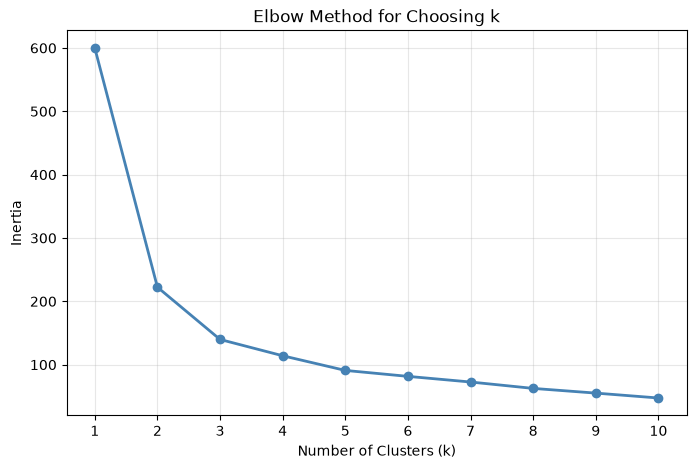

In [3]:
MAX_K = 10
inertias = []
for k in range(1, MAX_K + 1):
    kmeans_test = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    kmeans_test.fit(X_scaled)
    inertias.append(kmeans_test.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, MAX_K + 1), inertias, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Choosing k')
plt.xticks(range(1, MAX_K + 1))
plt.grid(True, alpha=0.3)
plt.show()

## Step 3: Run K-Means clustering

Note that the true species labels (`true_labels`) are never passed into `KMeans` —
this is genuinely unsupervised learning. We use k=3 based on the elbow plot above
(which conveniently also matches the 3 known species, though the algorithm was never
told this).

In [4]:
NUM_CLUSTERS = 3
kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=RANDOM_SEED, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print(f'Cluster sizes: {np.bincount(cluster_labels)}')
print(f'Final inertia: {kmeans.inertia_:.2f}')

Cluster sizes: [53 50 47]
Final inertia: 139.82


## Step 4: Visualize the clusters

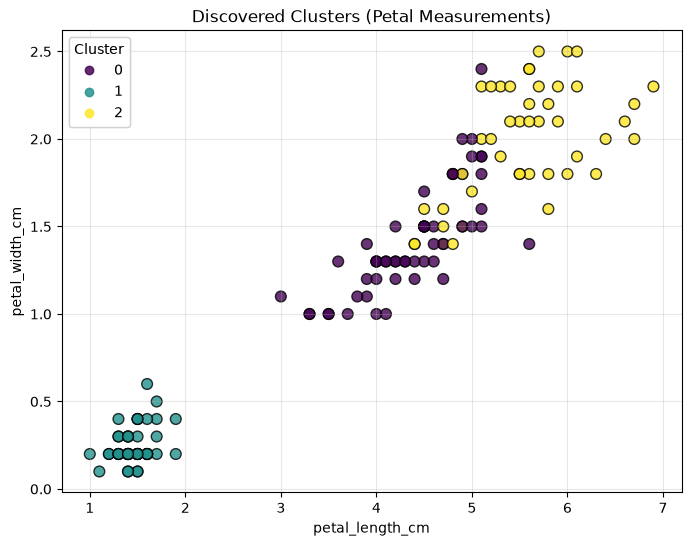

In [5]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_raw[:, 2], X_raw[:, 3], c=cluster_labels, cmap='viridis', s=60, edgecolor='k', alpha=0.8)
plt.xlabel(FEATURE_NAMES[2])
plt.ylabel(FEATURE_NAMES[3])
plt.title('Discovered Clusters (Petal Measurements)')
legend = plt.legend(*scatter.legend_elements(), title='Cluster')
plt.gca().add_artist(legend)
plt.grid(True, alpha=0.3)
plt.show()

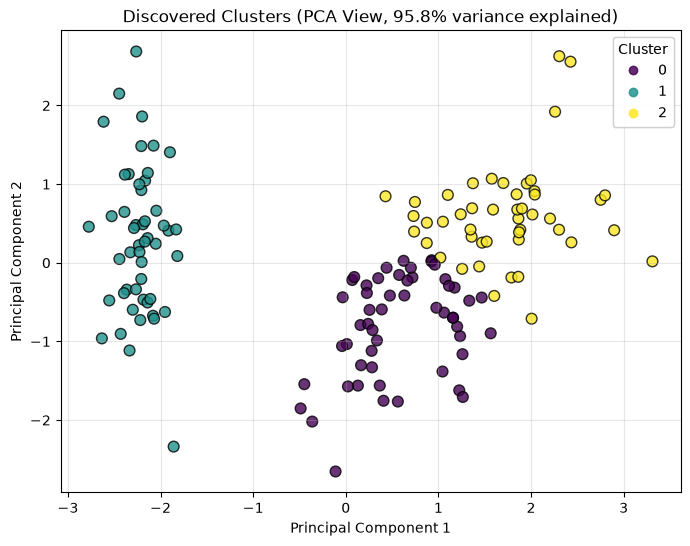

In [6]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_.sum() * 100

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=60, edgecolor='k', alpha=0.8)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Discovered Clusters (PCA View, {explained_variance:.1f}% variance explained)')
legend = plt.legend(*scatter.legend_elements(), title='Cluster')
plt.gca().add_artist(legend)
plt.grid(True, alpha=0.3)
plt.show()

## Step 5: Interpret the clusters

We now compare discovered clusters against the true species labels purely for
educational insight — in a real unsupervised problem, no true labels would exist
to check against.

In [7]:
cross_tab = np.zeros((NUM_CLUSTERS, len(SPECIES_NAMES)), dtype=int)
for cluster_id, species_id in zip(cluster_labels, true_labels):
    cross_tab[cluster_id, species_id] += 1

print(f"{'Cluster':<10}" + ''.join(f'{name:>14}' for name in SPECIES_NAMES))
for cluster_id in range(NUM_CLUSTERS):
    row = f'{cluster_id:<10}' + ''.join(f'{cross_tab[cluster_id, s]:>14}' for s in range(len(SPECIES_NAMES)))
    print(row)

print()
for cluster_id in range(NUM_CLUSTERS):
    mask = cluster_labels == cluster_id
    avg_features = X_raw[mask].mean(axis=0)
    dominant_species_id = int(np.argmax(cross_tab[cluster_id]))
    dominant_species = SPECIES_NAMES[dominant_species_id]
    total = cross_tab[cluster_id].sum()
    match_percent = cross_tab[cluster_id, dominant_species_id] / total * 100 if total else 0
    print(f'Cluster {cluster_id} ({total} flowers) most closely resembles "{dominant_species}" ({match_percent:.0f}% match)')
    for name, value in zip(FEATURE_NAMES, avg_features):
        print(f'    {name}: {value:.2f} cm')

Cluster           setosa    versicolor     virginica
0                      0            39            14
1                     50             0             0
2                      0            11            36

Cluster 0 (53 flowers) most closely resembles "versicolor" (74% match)
    sepal_length_cm: 5.80 cm
    sepal_width_cm: 2.67 cm
    petal_length_cm: 4.37 cm
    petal_width_cm: 1.41 cm
Cluster 1 (50 flowers) most closely resembles "setosa" (100% match)
    sepal_length_cm: 5.01 cm
    sepal_width_cm: 3.43 cm
    petal_length_cm: 1.46 cm
    petal_width_cm: 0.25 cm
Cluster 2 (47 flowers) most closely resembles "virginica" (77% match)
    sepal_length_cm: 6.78 cm
    sepal_width_cm: 3.10 cm
    petal_length_cm: 5.51 cm
    petal_width_cm: 1.97 cm


## Summary

This notebook covered a complete, real, end-to-end unsupervised machine learning
(clustering) workflow: loading and standardizing data, using the elbow method to pick
a cluster count, running K-Means without any labels, visualizing the discovered
clusters, and interpreting them in plain language.

K-Means found these groupings using only the raw measurements — it was never told
which flower belonged to which species. The fact that discovered clusters line up
reasonably well with real species is strong evidence of genuine structure in the
data, not something we imagined.

**Try it yourself:** change `NUM_CLUSTERS` above (e.g., to 2 or 4) and re-run the
notebook (`Runtime → Run all`) to see how the groupings change.